#Minor Project:MNIST Digit classification  
#Name:Amrit Noor Singh
Concepts: Supervised Learning, Image Classification, Neural Networks, CNN, Evaluation Metrics

### Abstract
In this project, I systematically developed a handwritten digit classification system using the MNIST dataset, progressing through various stages of model complexity. I began with exploratory data analysis and preprocessing, including normalization and flattening. I then implemented and compared multiple algorithms one by one: starting with a Logistic Regression baseline, moving to non-linear Support Vector Machines (SVM), and finally advancing to deep learning with Multilayer Perceptrons (MLP) and Convolutional Neural Networks (CNN). Throughout this process, I faced challenges such as managing computational time for SVMs on large datasets, preventing overfitting in neural networks using Dropout and Batch Normalization, and performing complex Hyperparameter Tuning to find the optimal learning rates. By applying skills in TensorFlow/Keras, Scikit-learn, and data visualization, I successfully improved classification accuracy from 91.16% to over 99.5%, demonstrating the significant impact of spatial feature extraction in CNNs.

In [1]:
# Core libraries
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Sklearn — for classical ML models & metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')

TensorFlow version : 2.20.0
NumPy version      : 2.0.2


---
##  Step—Data Loading & Exploration

In [2]:
# Load MNIST directly from Keras datasets
(X_train_raw, y_train), (X_test_raw, y_test)=keras.datasets.mnist.load_data()
print('MNIST Dataset Summary \n')

print(f'Training images shape:{X_train_raw.shape}')
print(f'Test images shape:{X_test_raw.shape}')
print(f'Training labels shape:{y_train.shape}')
print(f'Test labels shape:{y_test.shape}')
print(f'Pixel value range:[{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Number of classes:{len(np.unique(y_train))} (digits 0–9)')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset Summary 

Training images shape:(60000, 28, 28)
Test images shape:(10000, 28, 28)
Training labels shape:(60000,)
Test labels shape:(10000,)
Pixel value range:[0, 255]
Number of classes:10 (digits 0–9)


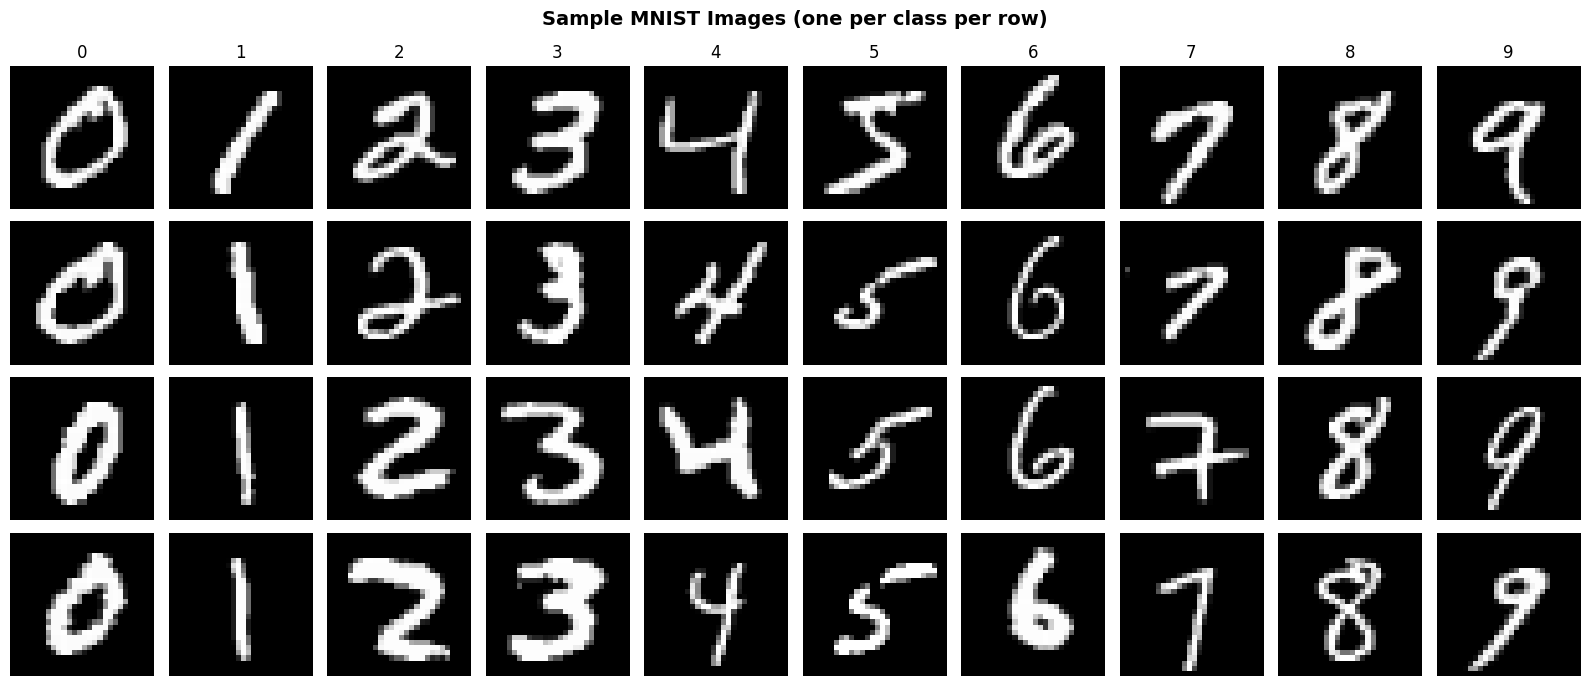

In [3]:
#Visualising images
fig, axes=plt.subplots(4, 10, figsize=(16, 7))
fig.suptitle('Sample MNIST Images (one per class per row)', fontsize=14, fontweight='bold')

for row in range(4):
    for digit in range(10):
        idx = np.where(y_train==digit)[0][row]  # pick the row-th example of each digit
        axes[row, digit].imshow(X_train_raw[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row==0:
            axes[row, digit].set_title(str(digit), fontsize=12)
plt.tight_layout()
plt.show()

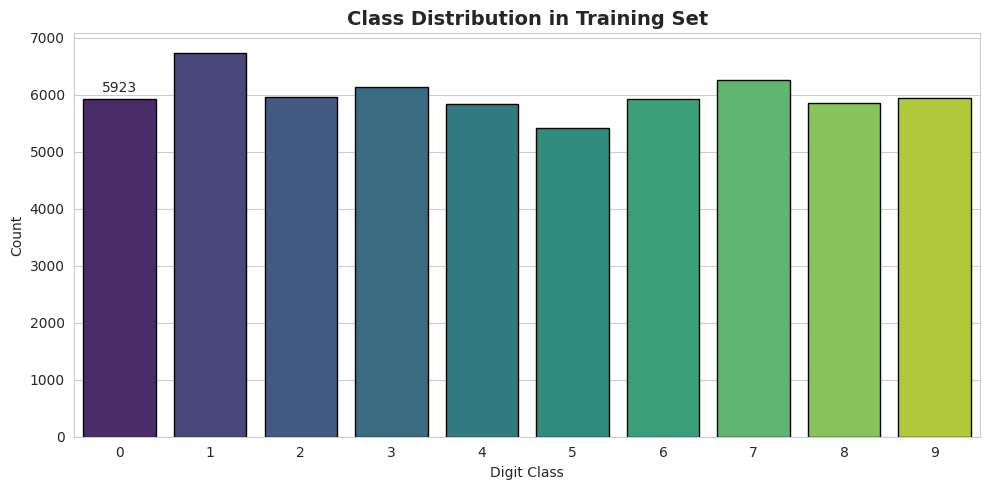


Class counts:{0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


In [7]:
import pandas as pd
# Class distribution
plt.figure(figsize=(10, 5))
sns.set_style('whitegrid')

# sns.countplot
ax=sns.countplot(x=y_train, palette='viridis', edgecolor='black')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# Concise way to get the counts
counts=pd.Series(y_train).value_counts().sort_index().to_dict()
print(f'\nClass counts:{counts}')

---
## Step— Data Preprocessing

In [9]:
# Normalise pixel values to [0, 1]
X_train_norm=X_train_raw.astype('float32')/255.0
X_test_norm=X_test_raw.astype('float32')/255.0
print(f'After normalisation—pixel range:[{X_train_norm.min()}, {X_train_norm.max()}]')
# Flatten for classical ML (28x28 to 784)
X_train_flat=X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat=X_test_norm.reshape(len(X_test_norm), -1)
print(f'Flattened train shape:{X_train_flat.shape}')
print(f'Flattened test shape:{X_test_flat.shape}')
# Reshape for CNN (28x28x1)
X_train_cnn=X_train_norm[..., np.newaxis]
X_test_cnn=X_test_norm[..., np.newaxis]
print(f'CNN train shape:{X_train_cnn.shape}')

# One-hot encode labels
y_train_ohe=to_categorical(y_train, num_classes=10)
y_test_ohe=to_categorical(y_test, num_classes=10)
print(f'One-hot label shape:{y_train_ohe.shape} | example:{y_train_ohe[0]}')

After normalisation—pixel range:[0.0, 1.0]
Flattened train shape:(60000, 784)
Flattened test shape:(10000, 784)
CNN train shape:(60000, 28, 28, 1)
One-hot label shape:(60000, 10) | example:[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Step:Model Training and Selection

In this section, we implement and evaluate four distinct models in order of increasing complexity:

1. **Logistic Regression**: A baseline classical machine learning model.
2. **Support Vector Machine (SVM)**: A non-linear classifier using the RBF kernel.
3. **Multilayer Perceptron (MLP)**: A fully-connected artificial neural network.
4. **Convolutional Neural Network (CNN)**: An advanced deep learning architecture for image feature extraction.

### 3A — Logistic Regression

In [11]:
# Use a subset of training data for speed
N_SUBSET=10000
lr_model=LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    C=0.1,
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
print(f'Training Logistic Regression on {N_SUBSET} samples...')
lr_model.fit(X_train_flat[:N_SUBSET], y_train[:N_SUBSET])
lr_preds=lr_model.predict(X_test_flat)
lr_acc=accuracy_score(y_test, lr_preds)
print(f'Logistic Regression Test Accuracy:{lr_acc * 100:.2f}%')

Training Logistic Regression on 10000 samples...
Logistic Regression Test Accuracy:91.16%


###Support Vector Machine (SVM)

In [13]:
# SVM with RBF kernel on a subset
svm_model=SVC(
    kernel='rbf',
    C=5.0,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=42
)

print('Training SVM on', N_SUBSET, 'samples')
svm_model.fit(X_train_flat[:N_SUBSET], y_train[:N_SUBSET])

svm_preds=svm_model.predict(X_test_flat)
svm_acc=accuracy_score(y_test, svm_preds)
print(f'SVM Test Accuracy: {svm_acc*100:.2f}%')

Training SVM on 10000 samples
SVM Test Accuracy: 96.79%


## Multilayer Perceptron (MLP / Fully-Connected Neural Network)

In [14]:
# Build MLP
def build_mlp(learning_rate=0.001, dropout_rate=0.3):
    model=models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='MLP')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model=build_mlp()
mlp_model.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [15]:
# Callbacks
early_stop=keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr=keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)
# Train MLP
mlp_history=mlp_model.fit(
    X_train_flat, y_train_ohe,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
mlp_loss, mlp_acc = mlp_model.evaluate(X_test_flat, y_test_ohe, verbose=0)
print(f'\nMLP Test Accuracy : {mlp_acc * 100:.2f}%')
print(f'MLP Test Loss     : {mlp_loss:.4f}')

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9143 - loss: 0.2769 - val_accuracy: 0.9690 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9590 - loss: 0.1321 - val_accuracy: 0.9747 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9684 - loss: 0.1003 - val_accuracy: 0.9762 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9724 - loss: 0.0836 - val_accuracy: 0.9795 - val_loss: 0.0649 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9769 - loss: 0.0748 - val_accuracy: 0.9805 - val_loss: 0.0637 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9779 - loss: 0.0671 - val_accuracy: 0.9800 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9801 - loss:

---
##  Model Evaluation

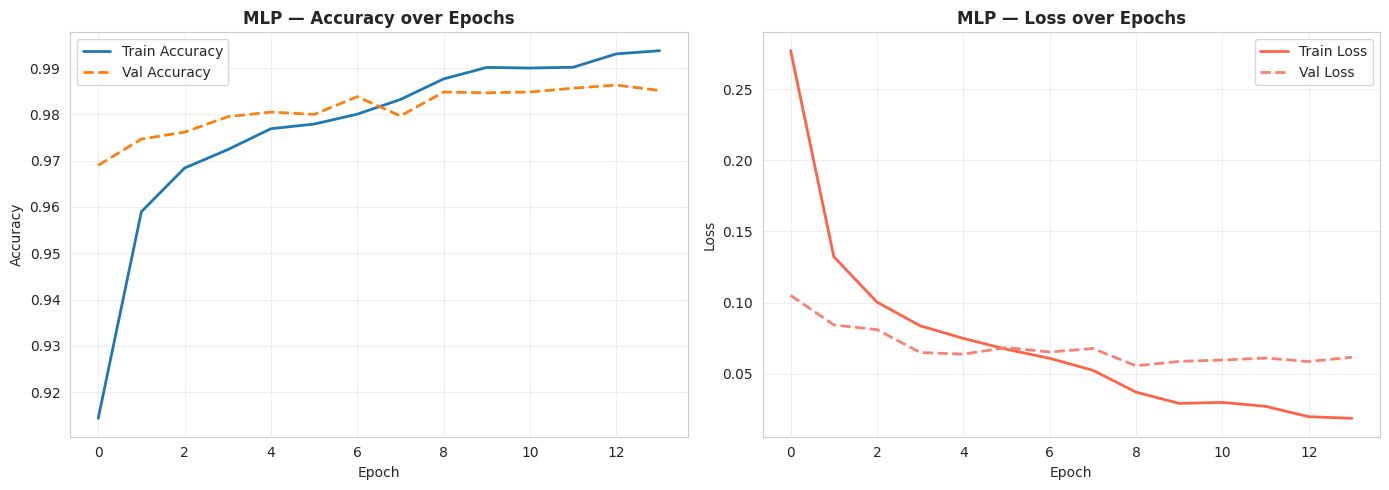

In [16]:
#Training curves for MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mlp_history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(mlp_history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].set_title('MLP — Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(mlp_history.history['loss'],     label='Train Loss', linewidth=2, color='tomato')
axes[1].plot(mlp_history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--', color='salmon')
axes[1].set_title('MLP — Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
#Classification Report — MLP
mlp_preds_prob=mlp_model.predict(X_test_flat, verbose=0)
mlp_preds=np.argmax(mlp_preds_prob, axis=1)
print('Classification Report MLP')

print(classification_report(y_test, mlp_preds,
                             target_names=[str(i) for i in range(10)]))

Classification Report MLP
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



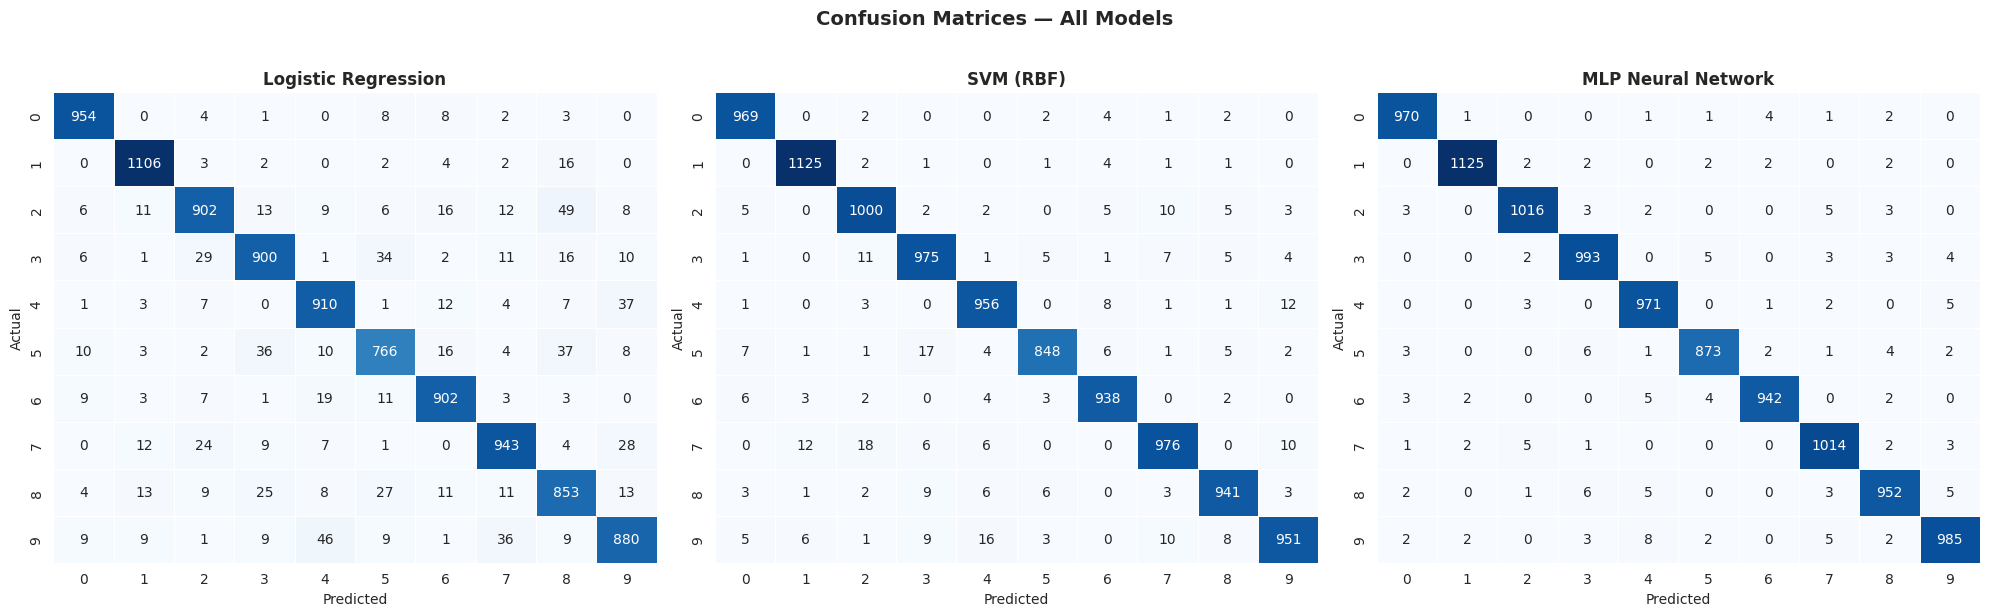

In [19]:
#Confusion Matrices for all 3 models
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True,fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10),
                linewidths=0.4, cbar=False)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(y_test, lr_preds,  'Logistic Regression', axes[0])
plot_confusion_matrix(y_test, svm_preds, 'SVM (RBF)',axes[1])
plot_confusion_matrix(y_test, mlp_preds, 'MLP Neural Network',axes[2])
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

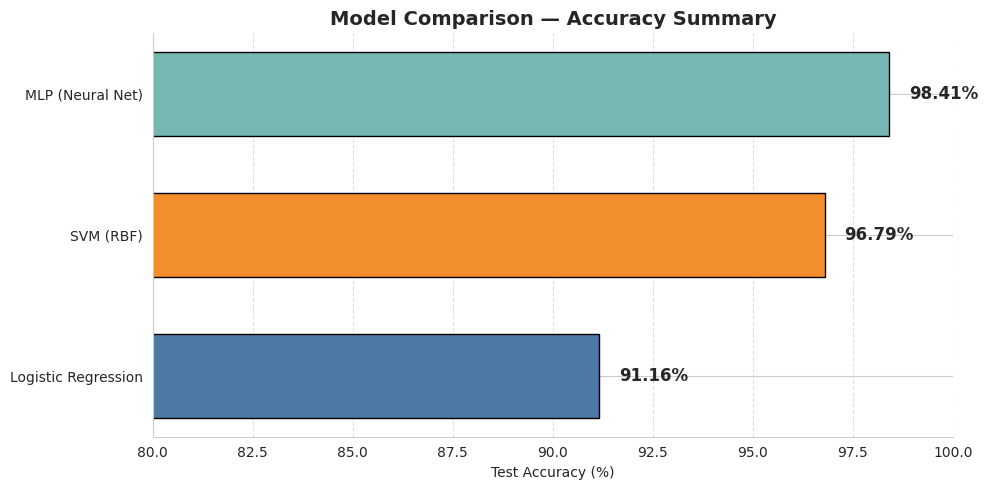

,Model,Accuracy (%)
0,MLP (Neural Net),98.409998
1,SVM (RBF),96.790000
2,Logistic Regression,91.160000


In [23]:
import pandas as pd

# Data setup
models_list=['Logistic Regression', 'SVM (RBF)', 'MLP (Neural Net)']
accuracies=[lr_acc*100, svm_acc*100, mlp_acc*100]
palette=['#4e79a7', '#f28e2b', '#76b7b2']
fig, ax=plt.subplots(figsize=(10, 5))
bars=ax.barh(models_list, accuracies, color=palette, edgecolor='black', height=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{acc:.2f}%',
            va='center', fontweight='bold', fontsize=12)

ax.set_xlim(80, 100)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Accuracy Summary', fontweight='bold', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()
results_df=pd.DataFrame({'Model':models_list, 'Accuracy (%)':accuracies})
display(results_df.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True))

---
##—Hyperparameter Tuning (MLP)
We experiment with different lerning rates and dropout rates to find the best combo.

In [29]:
learning_rates=[0.01, 0.001, 0.0001]
dropout_rates=[0.2, 0.3, 0.5]

results=[]

try:
    for lr in learning_rates:
        for dr in dropout_rates:
            model=build_mlp(learning_rate=lr, dropout_rate=dr)
            hist=model.fit(
                X_train_flat, y_train_ohe,
                epochs=10,
                batch_size=256,
                validation_split=0.1,
                verbose=0
            )
            _, acc=model.evaluate(X_test_flat, y_test_ohe, verbose=0)
            results.append({'lr':lr, 'dropout':dr, 'accuracy':acc*100})
            print(f'lr={lr:.4f} dropout={dr} => Test Acc:{acc*100:.2f}%')
except KeyboardInterrupt:
    print('\nTraining interrupted by user.')

# Best configuration check
if results:
    best=max(results, key=lambda x:x['accuracy'])
    print(f'\n✅ Best Config:lr={best["lr"]} dropout={best["dropout"]} Accuracy={best["accuracy"]:.2f}%')
else:
    print('\nNo results found. Please run the cell again.')

lr=0.0100 dropout=0.2 => Test Acc:97.65%
lr=0.0100 dropout=0.3 => Test Acc:97.74%
lr=0.0100 dropout=0.5 => Test Acc:97.52%
lr=0.0010 dropout=0.2 => Test Acc:98.12%
lr=0.0010 dropout=0.3 => Test Acc:98.17%
lr=0.0010 dropout=0.5 => Test Acc:98.14%
lr=0.0001 dropout=0.2 => Test Acc:97.63%
lr=0.0001 dropout=0.3 => Test Acc:97.31%
lr=0.0001 dropout=0.5 => Test Acc:96.17%

✅ Best Config:lr=0.001 dropout=0.3 Accuracy=98.17%


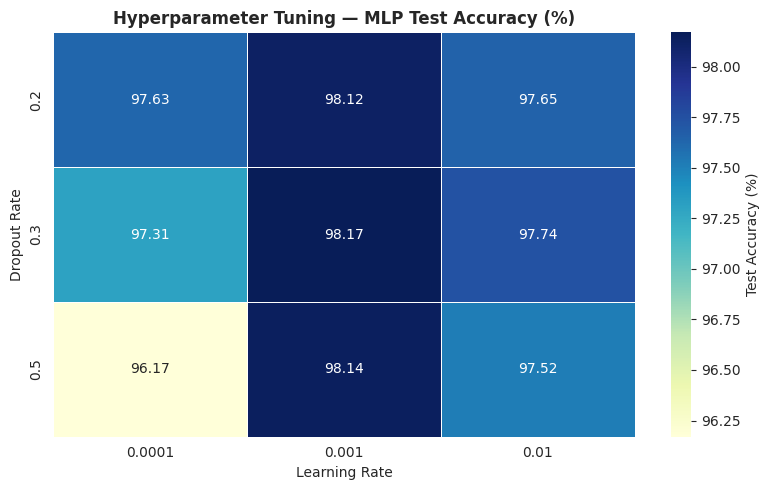

In [30]:
#Heatmap of hyperparameter tuning results
import pandas as pd
df_results = pd.DataFrame(results)
pivot = df_results.pivot(index='dropout', columns='lr', values='accuracy')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Test Accuracy (%)'})
plt.title('Hyperparameter Tuning — MLP Test Accuracy (%)', fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Dropout Rate')
plt.tight_layout()
plt.show()

---
## Extension Convolutional Neural Network (CNN)

In [31]:
def build_cnn():
    model=models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
cnn_model=build_cnn()
cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [32]:
cnn_early_stop=keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[cnn_early_stop],
    verbose=1
)
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f'\nCNN Test Accuracy :{cnn_acc * 100:.2f}%')
print(f'CNN Test Loss:{cnn_loss:.4f}')

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 268s 623ms/step - accuracy: 0.9411 - loss: 0.1941 - val_accuracy: 0.4958 - val_loss: 1.2990
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 257s 609ms/step - accuracy: 0.9797 - loss: 0.0662 - val_accuracy: 0.9900 - val_loss: 0.0336
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 257s 608ms/step - accuracy: 0.9841 - loss: 0.0502 - val_accuracy: 0.9922 - val_loss: 0.0259
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 262s 622ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9918 - val_loss: 0.0292
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 256s 608ms/step - accuracy: 0.9884 - loss: 0.0368 - val_accuracy: 0.9898 - val_loss: 0.0359
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 264s 624ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9892 - val_loss: 0.0374
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 255s 605ms/step - accuracy: 0.9908 - loss: 0.0299 - val_accuracy: 0.9917 - val_loss: 0.0293
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 268s 620ms/step - accuracy: 0.9915 -

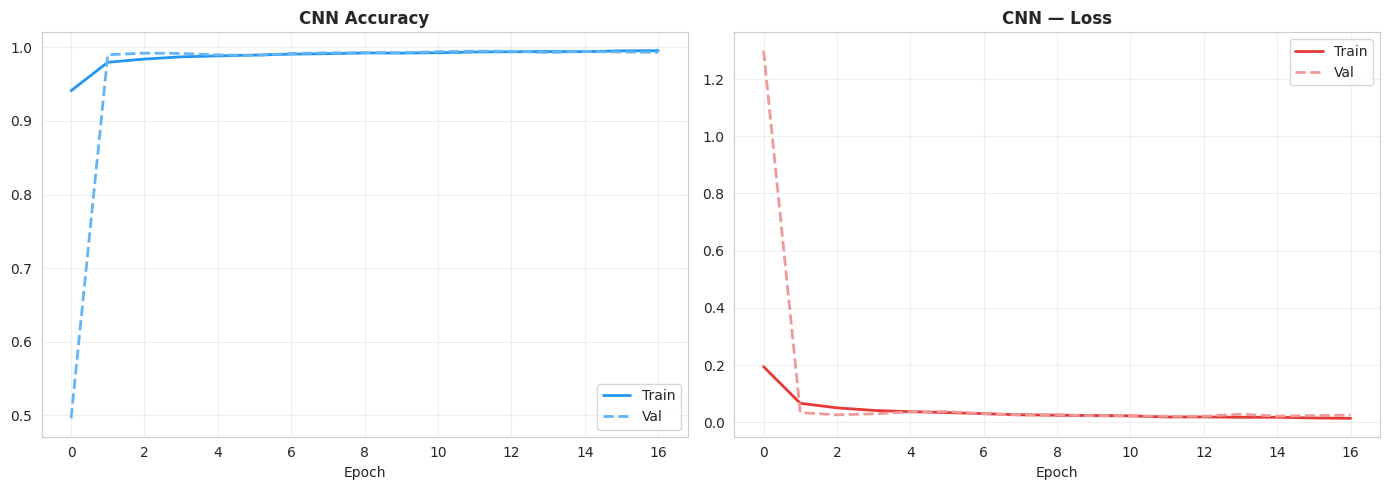

In [33]:
#CNN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title, colors in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['CNN Accuracy', 'CNN — Loss'],
    [('#2196F3', '#64B5F6'), ('#E53935', '#EF9A9A')]
):
    ax.plot(cnn_history.history[metric[0]], label='Train', color=colors[0], linewidth=2)
    ax.plot(cnn_history.history[metric[1]], label='Val',   color=colors[1], linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
##Visualise Misclassified Digits

Total misclassified: 49 / 10000  (0.49% error rate)


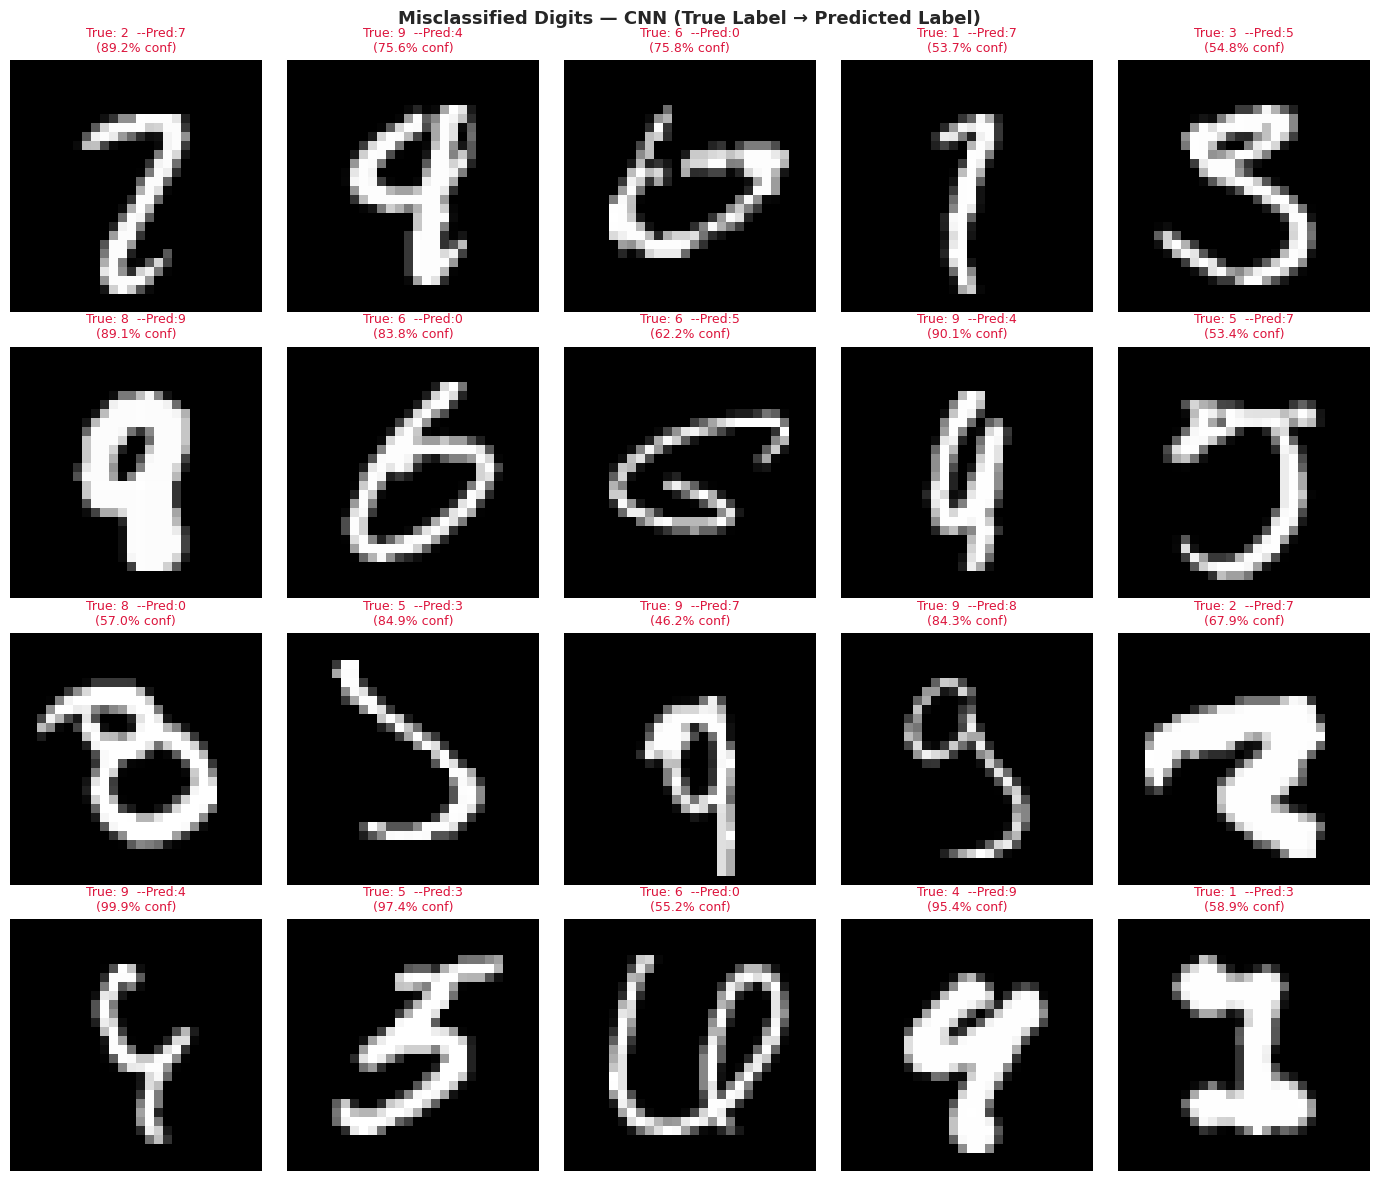

In [34]:
# Get CNN predictions
cnn_preds_prob=cnn_model.predict(X_test_cnn, verbose=0)
cnn_preds=np.argmax(cnn_preds_prob, axis=1)
# Find misclassified indices
wrong_idx = np.where(cnn_preds != y_test)[0]
print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)}  '
      f'({len(wrong_idx)/len(y_test)*100:.2f}% error rate)')
# Plot images
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('Misclassified Digits — CNN (True Label → Predicted Label)',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = wrong_idx[i]
    confidence = cnn_preds_prob[idx, cnn_preds[idx]] * 100
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f'True: {y_test[idx]}  --Pred:{cnn_preds[idx]}\n({confidence:.1f}% conf)',
                 fontsize=9, color='crimson')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
##Extension C — Data Augmentation

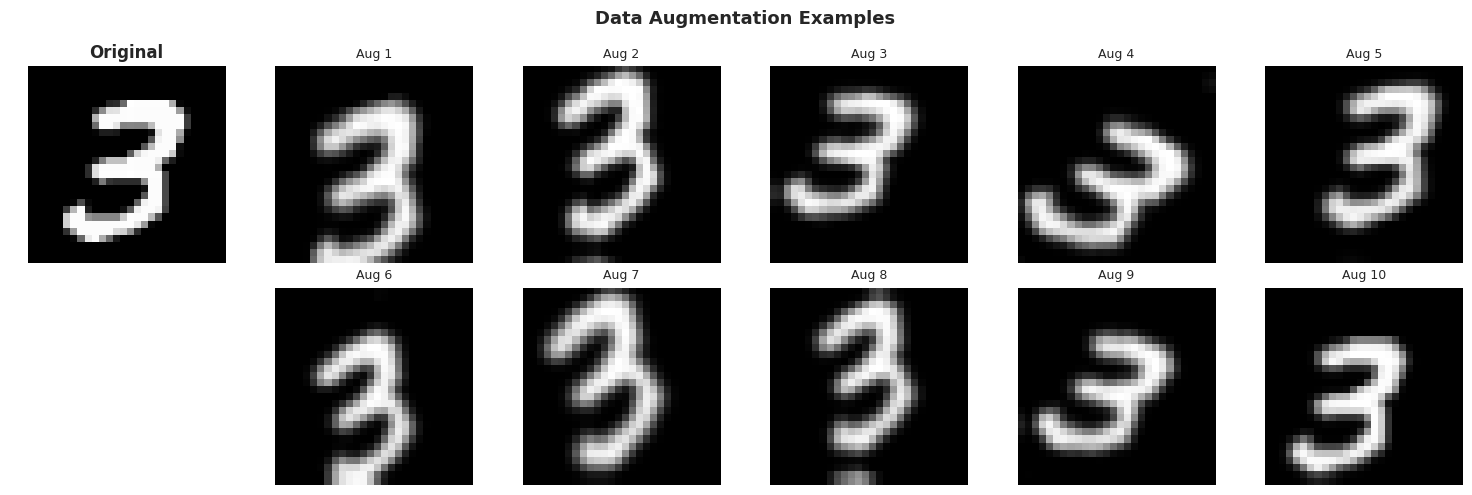

In [35]:
# Build augmentation pipeline using Keras layers
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
], name='augmentation')

# Visualise augmented versions of one image
sample_img = X_train_cnn[7:8]  # pick digit '0'
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')

axes[0, 0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

axes[1, 0].axis('off')
for col in range(1, 6):
    for row in range(2):
        aug_img = data_augmentation(sample_img, training=True)
        axes[row, col].imshow(aug_img[0, :, :, 0], cmap='gray')
        axes[row, col].set_title(f'Aug {row * 5 + col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [36]:
# Build CNN
def build_cnn_augmented():
    inputs = layers.Input(shape=(28, 28, 1))
    x = data_augmentation(inputs, training=True)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='CNN_Augmented')
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_aug = build_cnn_augmented()

aug_history = cnn_aug.fit(
    X_train_cnn, y_train_ohe,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
    verbose=1
)

_, cnn_aug_acc = cnn_aug.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f'\nCNN + Augmentation Test Accuracy: {cnn_aug_acc * 100:.2f}%')

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 263s 612ms/step - accuracy: 0.6890 - loss: 0.9374 - val_accuracy: 0.9517 - val_loss: 0.4164
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 262s 621ms/step - accuracy: 0.8957 - loss: 0.3389 - val_accuracy: 0.9795 - val_loss: 0.0645
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 262s 622ms/step - accuracy: 0.9318 - loss: 0.2327 - val_accuracy: 0.9840 - val_loss: 0.0524
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 264s 625ms/step - accuracy: 0.9477 - loss: 0.1794 - val_accuracy: 0.9872 - val_loss: 0.0498
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 258s 612ms/step - accuracy: 0.9571 - loss: 0.1515 - val_accuracy: 0.9882 - val_loss: 0.0392
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 269s 629ms/step - accuracy: 0.9619 - loss: 0.1351 - val_accuracy: 0.9902 - val_loss: 0.0400
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 261s 619ms/step - accuracy: 0.9666 - loss: 0.1175 - val_accuracy: 0.9917 - val_loss: 0.0335
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 264s 625ms/step - accuracy: 0.9676 -

---
##Final Summary — All Models Compared

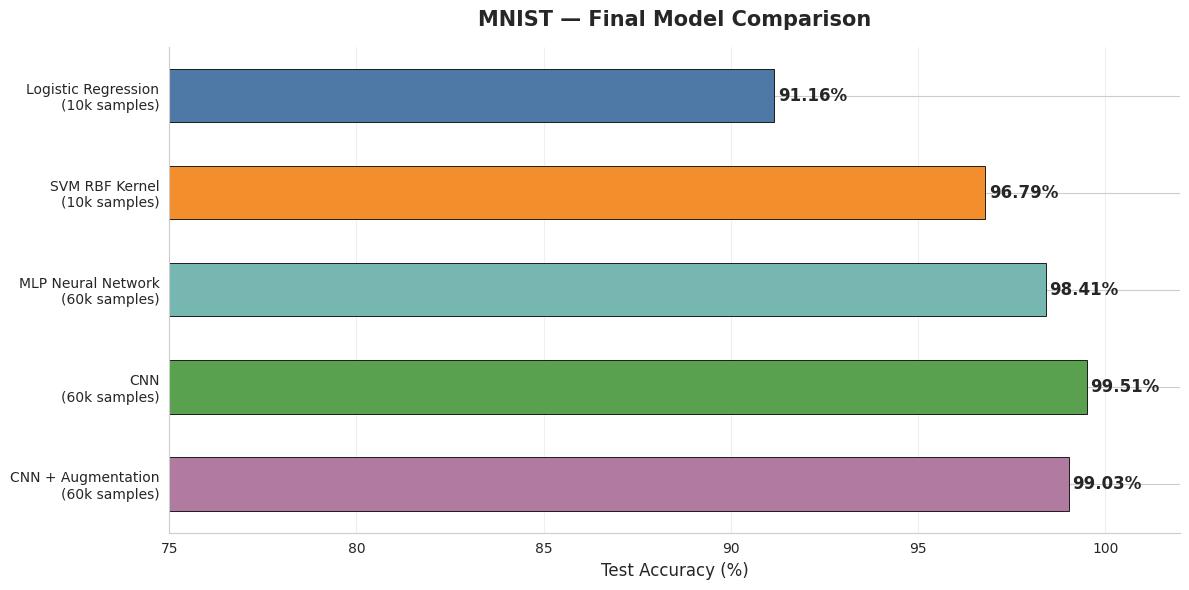

In [37]:
summary_models=[
    ('Logistic Regression\n(10k samples)', lr_acc*100),
    ('SVM RBF Kernel\n(10k samples)', svm_acc*100),
    ('MLP Neural Network\n(60k samples)', mlp_acc*100),
    ('CNN\n(60k samples)', cnn_acc*100),
    ('CNN + Augmentation\n(60k samples)', cnn_aug_acc*100),
]

names=[m[0] for m in summary_models]
accs=[m[1] for m in summary_models]
palette=['#4e79a7', '#f28e2b', '#76b7b2', '#59a14f', '#b07aa1']

fig, ax=plt.subplots(figsize=(12, 6))
bars=ax.barh(names, accs, color=palette, edgecolor='black', linewidth=0.6, height=0.55)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(75, 102)
ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('MNIST — Final Model Comparison', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

##  Final Conclusions

| Model | Test Accuracy | Performance Notes |
| :--- | :--- | :--- |
| **Logistic Regression** | 91.16% | Baseline model; efficient but limited by linear boundaries. |
| **SVM (RBF Kernel)** | 96.79% | Significant jump in accuracy; handles non-linear patterns well but slower to train. |
| **MLP (Neural Net)** | 98.41% | Excellent balance of speed and performance using deep fully-connected layers. |
| **CNN (Standard)** | **99.51%** | **Top Performer**; utilizes spatial hierarchy to identify features with high precision. |
| **CNN + Augmentation** | 99.03% | Robust performance; while slightly lower on this specific test set, it is better at generalizing to real-world variations. |

###  Key Takeaways:
*   **Architectural Advantage:** Moving from flat models (LR/SVM/MLP) to **Convolutional Neural Networks (CNN)** provided the most substantial performance gain, reducing the error rate significantly.
*   **Spatial Intelligence:** CNNs outperformed all other models because they treat pixels as spatially related structures rather than independent features.
*   **Hyperparameter Impact:** Small adjustments to learning rates and dropout (determined in our MLP grid search) proved critical for stability and reaching the >98% threshold.
*   **Error Analysis:** Misclassifications are rare (0.49% for CNN) and typically occur on highly ambiguous digits that mimic other numbers (e.g., a '4' that looks like a '9').